In [7]:
from astropy.io import fits
import os
from astropy.visualization import make_lupton_rgb
from astropy.visualization import PercentileInterval
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits
from astropy.nddata import Cutout2D
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord

from scipy.ndimage import rotate

import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt
import os


In [1]:
base = "/xdisk/egami/aakhtarkavan/edr_products/sapphires_edr_nircam_sci"

filters = ["F200W","F277W","F444W"]

for filt in filters:
    path = os.path.join(
        base,
        f"4750_{filt}_v05_sci.fits"
    )

    with fits.open(path) as hdul:

        data = hdul[0].data

        print(f"{filt}")
        print(f"Shape: {data.shape}")
        print()

F200W
Shape: (12000, 12000)

F277W
Shape: (12000, 12000)

F444W
Shape: (12000, 12000)



/home/u7/aakhtarkavan/miniconda3/envs/geko_env/lib/python3.11/site-packages/astropy/visualization/lupton_rgb.py:645: RuntimeWarning: invalid value encountered in divide
  fInorm = np.where(Int <= 0, 0, np.true_divide(fI, Int))


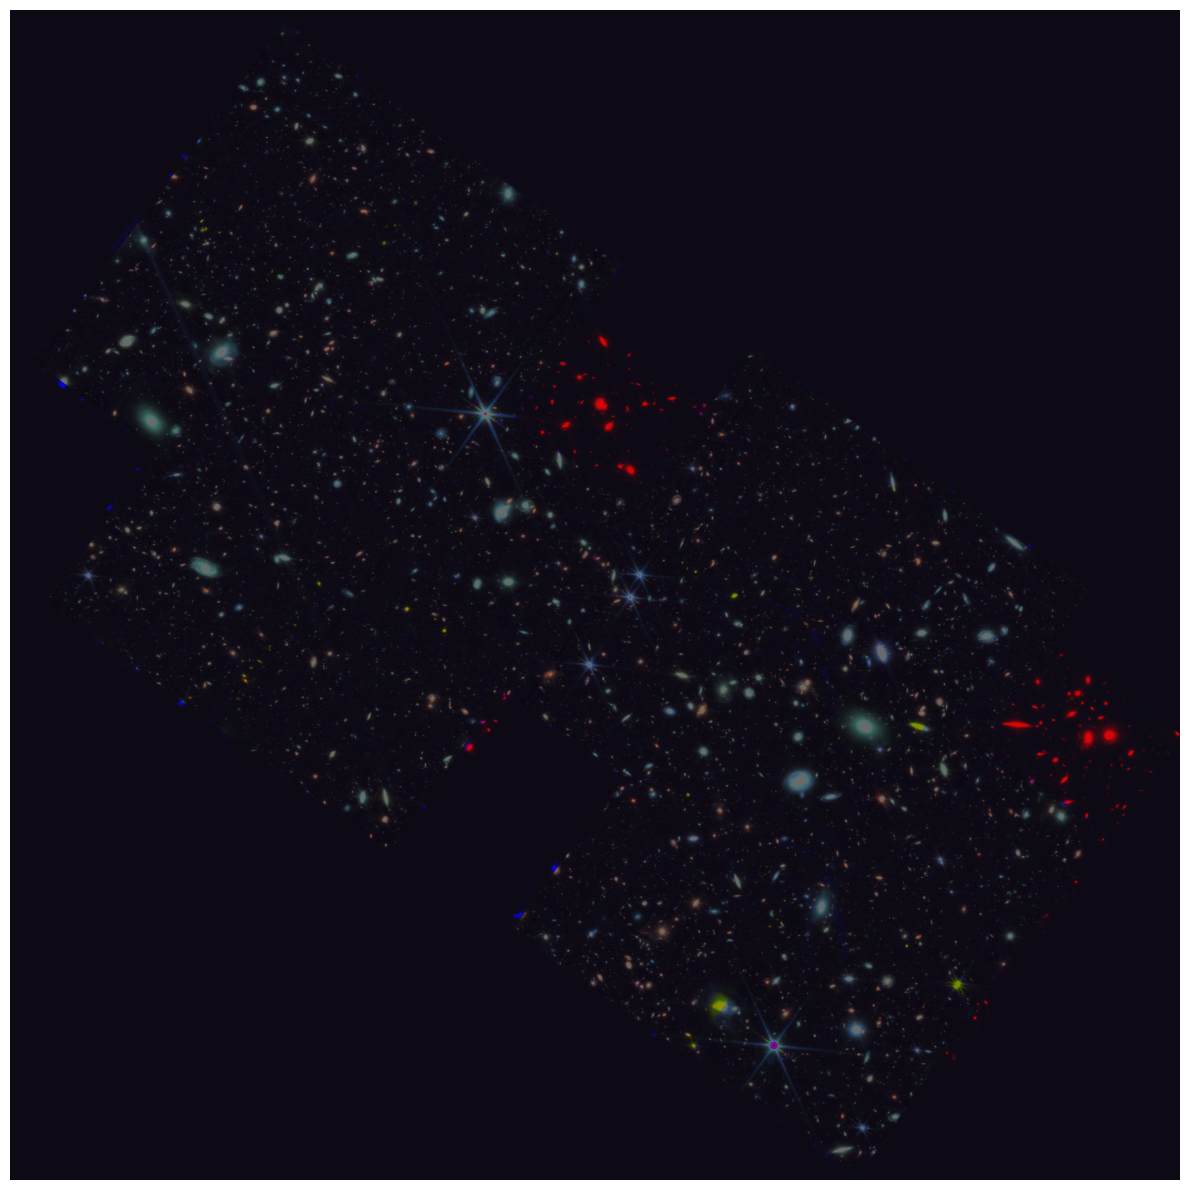

In [3]:
base = "/xdisk/egami/aakhtarkavan/edr_products/sapphires_edr_nircam_sci"

f200w_file = f"{base}/4750_F200W_v05_sci.fits"
f277w_file = f"{base}/4750_F277W_v05_sci.fits"
f444w_file = f"{base}/4750_F444W_v05_sci.fits"

f200w = fits.getdata(f200w_file)
f277w = fits.getdata(f277w_file)
f444w = fits.getdata(f444w_file)

f200w = np.nan_to_num(f200w, nan=0.0)
f277w = np.nan_to_num(f277w, nan=0.0)
f444w = np.nan_to_num(f444w, nan=0.0)

interval = PercentileInterval(99.5)

f200w = interval(f200w)
f277w = interval(f277w)
f444w = interval(f444w)

rgb = make_lupton_rgb(
    f444w,   # RED
    f277w,   # GREEN
    f200w,   # BLUE
    stretch=0.5,
    Q=10
)

plt.figure(figsize=(12,12))
plt.imshow(rgb, origin='lower')
plt.axis('off')
plt.tight_layout()
# plt.savefig(
#     "/home/u7/aakhtarkavan/git_projects/Galaxy_Kinematics/colored_images/F200_277_444W_rgb.png",
#     dpi=300,
#     bbox_inches='tight',
#     pad_inches=0
# )
fits.writeto(
    f"colored_images/cutouts/{ID}_rgb_rot.fits",
    rot_rgb,
    overwrite=True
)


plt.show()

In [14]:
ID = 6170
ROT_ANGLE = -35.74
size = (120, 120)

filters = {
    "blue":  "F200W",
    "green": "F277W",
    "red":   "F444W"
}

BASE_DIRECTORY = "/home/u7/aakhtarkavan/kinematics/"
BASE_EDR_DATA_DIRECTORY = "/xdisk/egami/aakhtarkavan/edr_products/"

Set DATE-AVG to '2024-11-05T05:57:22.214' from MJD-AVG.
Set DATE-END to '2024-11-05T18:25:42.993' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    22.063743 from OBSGEO-[XYZ].
Set OBSGEO-H to 1536619041.948 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-11-05T20:19:25.616' from MJD-AVG.
Set DATE-END to '2024-11-06T10:05:43.162' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.878584 from OBSGEO-[XYZ].
Set OBSGEO-H to 1541094443.023 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set DATE-AVG to '2024-11-05T06:21:53.611' from MJD-AVG.
Set DATE-END to '2024-11-06T04:53:48.940' from MJD-END'. [astropy.wcs.wcs]
Set OBSGEO-B to    21.915685 from OBSGEO-[XYZ].
Set OBSGEO-H to 1540200361.673 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/tmp/ipykernel_3884954/1136845845.py:59: RuntimeWarning: invalid value encountered in log10
  np.log10(img + 1e-2),


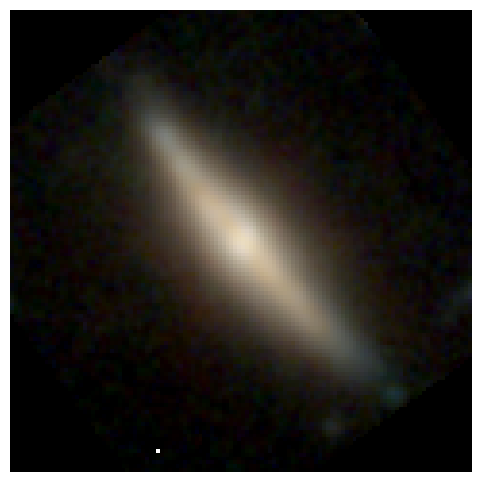

In [17]:
# LOAD CATALOG
spec = fits.getdata(
    f"{BASE_EDR_DATA_DIRECTORY}"
    "sapphires_edr_catalogs/"
    "sapphires_edr_spec_cat.fits"
)

row = spec[spec['ID'] == ID][0]

ra_source = row['RA']
dec_source = row['DEC']

coord = SkyCoord(
    ra=ra_source*u.deg,
    dec=dec_source*u.deg
)

# MAKE CUTOUT FUNCTION
def make_rotated_cutout(filter_name):

    sci_file = (
        f"{BASE_EDR_DATA_DIRECTORY}"
        f"sapphires_edr_nircam_sci/"
        f"4750_{filter_name}_v05_sci.fits"
    )

    hdu = fits.open(sci_file)

    data = hdu['SCI'].data

    wcs = WCS(hdu['SCI'].header)

    cutout = Cutout2D(
        data,
        position=coord,
        size=size,
        wcs=wcs
    )

    rot = rotate(
        cutout.data,
        angle=ROT_ANGLE,
        reshape=False
    )

    rot = np.nan_to_num(rot)

    return rot


# CUTOUTS
blue  = make_rotated_cutout(filters["blue"])
green = make_rotated_cutout(filters["green"])
red   = make_rotated_cutout(filters["red"])


# NORMALIZATION
def normalize(img):
    img = np.clip(np.log10(img + 1e-2), -2, 0.5)
    img = (img + 2) / 2.5
    return img

blue  = normalize(blue)
green = normalize(green)
red   = normalize(red)

# RGB CUBE
rgb_cube = np.dstack((red, green, blue))
rgb_cube = rgb_cube.astype(np.float32)

# SAVE FITS
os.makedirs("colored_images/cutouts", exist_ok=True)
fits.writeto(f"colored_images/cutouts/{ID}_rgb_rot.fits",rgb_cube,overwrite=True)

# DISPLAY IT
plt.figure(figsize=(6,6))
plt.imshow(rgb_cube, origin='lower')
plt.axis('off')

# SAVE AS PNG
plt.savefig(
    f"colored_images/cutouts/{ID}_rgb_rot.png",
    dpi=300,
    bbox_inches='tight',
    pad_inches=0
)